# K-Means Clustering Model Training

Train a K-Means clustering model for email spam detection (unsupervised).

## Notebook Structure
1. Import modules
2. Load dataset
3. Split data
4. Create and train pipeline
5. Evaluate clustering
6. Visualize results
7. Save model (.pkl)

### 1. Import modules

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn import metrics
import joblib

# Add src to path to import local modules
sys.path.append(os.path.abspath("../"))
from src.load_data import load_250K_email_dataset
from src.preprocess import clean_text, clean_db_text
from src.config import MODEL_OUTPUT_DIR

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aungm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aungm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### 2. Load dataset

In [2]:
# df = load_250K_email_dataset()
from src.config import PROCESSED_DATA_DIR


df = pd.read_csv(PROCESSED_DATA_DIR / "cleaned_combined_v3.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (118988, 11)


,label,text,num_urls,num_exclamation,num_question,num_dollar,num_all_caps,num_numbers,word_count,capital_ratio,emoji_count
0,0,receiv nahou-msmbx01v [phonenumber] nahou- mic...,41,0,0,3,240,407,2319,0.145347,0
1,0,receiv nahou- [phonenumber] nacal-msmbx01v mic...,0,1,0,0,19,56,166,0.230851,0
2,0,receiv nahou-msmbx01v [phonenumber] nahou- mic...,3,0,1,0,26,60,132,0.293362,0
3,0,receiv nahou-msmbx01v [phonenumber] nahou- mic...,0,0,1,0,29,73,297,0.189843,0
4,0,receiv nahou- [phonenumber] nahou- microsoft s...,0,0,0,0,14,48,122,0.239183,0


### 3. Split data

In [3]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (95190,), Test set: (23798,)


### 4. Create and train pipeline

In [4]:
pipeline = Pipeline([
    # ('tfidf', TfidfVectorizer(preprocessor=clean_text, max_features=5000, stop_words='english')),
    ('tfidf', TfidfVectorizer(max_features=20000, stop_words='english')),
    ('kmeans', KMeans(n_clusters=2, random_state=42, n_init=10))
])

pipeline.fit(X_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### 5. Evaluate clustering

In [5]:
train_clusters = pipeline.predict(X_train)

# Map clusters to labels (0: ham, 1: spam)
cluster_0_labels = y_train[train_clusters == 0]
cluster_1_labels = y_train[train_clusters == 1]

map_0 = cluster_0_labels.mode()[0]
map_1 = cluster_1_labels.mode()[0]

print(f"Cluster 0 maps to: {map_0}")
print(f"Cluster 1 maps to: {map_1}")

test_clusters = pipeline.predict(X_test)
test_preds = np.where(test_clusters == 0, map_0, map_1)

print(metrics.classification_report(y_test, test_preds))


Cluster 0 maps to: 0
Cluster 1 maps to: 1
              precision    recall  f1-score   support

           0       0.62      0.69      0.65     11722
           1       0.66      0.60      0.63     12076

    accuracy                           0.64     23798
   macro avg       0.64      0.64      0.64     23798
weighted avg       0.64      0.64      0.64     23798



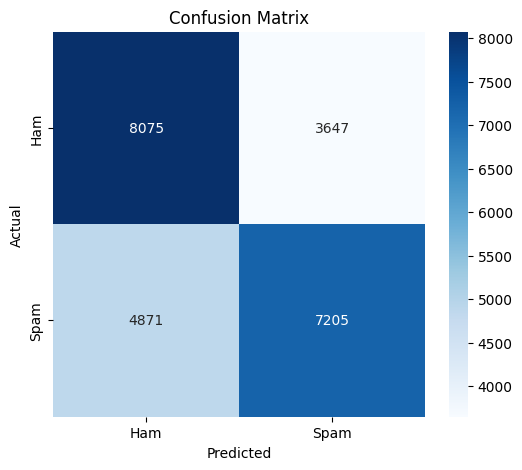

In [14]:
# confusion matrix 
from sklearn.metrics import confusion_matrix
test_clusters = pipeline.predict(X_test)
test_preds_mapped = np.where(test_clusters == 0, map_0, map_1)
cm = confusion_matrix(y_test, test_preds_mapped)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



### 6. Visualize results

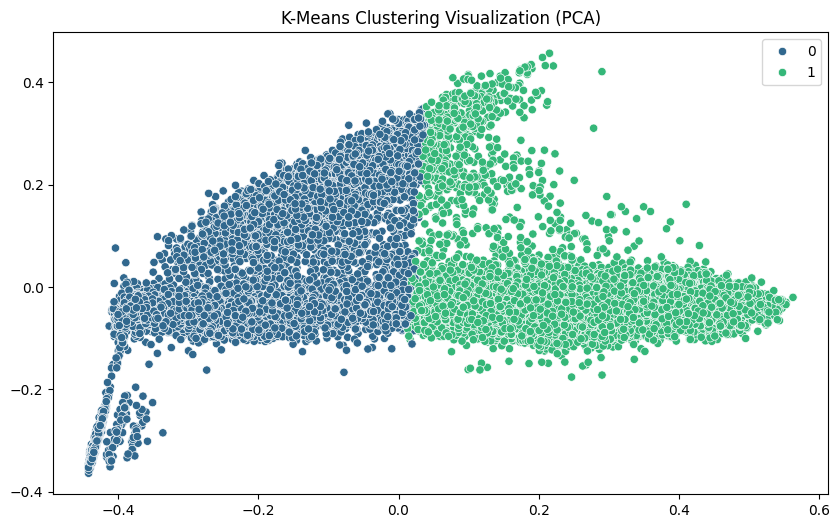

In [6]:
# Use PCA to reduce dimensions
tfidf_matrix = pipeline.named_steps['tfidf'].transform(X_test)
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=test_preds, palette='viridis')
plt.title('K-Means Clustering Visualization (PCA)')
plt.show()

### 7. Save model (.pkl)

In [7]:
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)
model_path = os.path.join(MODEL_OUTPUT_DIR, "kmeans_spam_model.pkl")
joblib.dump(pipeline, model_path)
print(f"Model saved to {model_path}")

Model saved to C:\Users\aungm\university\computing\cos30049-email-spam-detection\models\kmeans_spam_model.pkl


In [8]:
print(df[["text", "label"]].groupby("label").head(10).iloc[9]["text"] + "\n- label " + str(df[["text", "label"]].groupby("label").head(10).iloc[9]["label"]))
print(df[["text", "label"]].groupby("label").head(10).iloc[10]["text"] + "\n- label " + str(df[["text", "label"]].groupby("label").head(10).iloc[10]["label"]))

receiv nahou- [phonenumber] nahou- microsoft smtpsvc [phonenumber] fri [number] jun [phonenumber] [number] [number] [phonenumber] x-mimeol produc microsoft exchang v [phonenumber] content-class urncontent-classesmessag subject fmpa oil invoic date fri [number] jun [phonenumber] [number] [number] [phonenumber] mime-vers [number] [number] content-typ text/plain content-transfer-encod binari message-id x-ms-has-attach x-ms-tnef-correl thread-top fmpa oil invoic thread-index == "gimbl mathew" "weldon v charles" "brees mark" cc "fairley david" return-path [email] mark charli fmpa readi bill us oil coupl question want know send invoic refer email respons question steve mcelhaney fmpa [email] case forgot tell y'all go vacat right now [number] [number] cell phone check voicemail period thank help miss great fourth mathew
- label 0
receiv nahou- [phonenumber] napdx- microsoft smtpsvc [phonenumber] wed [number] jul [phonenumber] [number] [number] [phonenumber] receiv corpenroncom [phonenumber] n

### 8. Test Email Classification

In [16]:
from src.test_emails import test_emails
test_preds = pipeline.predict(test_emails)
mapped_preds = np.where(test_preds == 0, map_0, map_1)


for i, (email, pred) in enumerate(zip(test_emails, mapped_preds)):
    label = "SPAM" if pred == 1 else "HAM"
    print(f"[{i}] {label} — {email[:70]}...")







[0] HAM — Congratulations! You won $1000 free cash prize. Click here now to clai...
[1] HAM — Hi John, please find attached the meeting notes from yesterday's call....
[2] HAM — URGENT: Your account has been suspended. Verify now at http://scam-sit...
[3] HAM — Can we reschedule tomorrow's lunch to 1pm instead?...
[4] HAM — Buy cheap v1agra 100% free shipping limited offer act now!!!...
[5] HAM — For your Assignment 1, word count of 3100 is already slightly too high...
[6] HAM — Please be reminded that the Assignment 1 report is due this Sunday (17...
[7] HAM — Show, Last weekend, I was sick and couldn't do much of anything. So I ...
[8] HAM — Supporters can now pay you in USDC, and the money lands in your accoun...
[9] HAM — This email was sent to: SHOWWAIYAN555@GMAIL.COM You have received this...
[10] HAM — 
Payment Success for [ 26052270538 ]
Inbox

Fiuu <notification@fiuu.co...


In [15]:
# Get 6 ham and 5 spam samples from actual dataset
ham_samples = df[df["label"] == 0].sample(6, random_state=42)
spam_samples = df[df["label"] == 1].sample(5, random_state=42)


# show texts and labels
for i, row in enumerate(pd.concat([ham_samples, spam_samples]).itertuples()):
    label = "SPAM" if row.label == 1 else "HAM"
    print(f"[{i}] {label} — {row.text}...")


[0] HAM — reciev nahou- [phonenumber] nahou- microsoft smtpsvc [phonenumber] tue [number] sep [phonenumber] [number] [number] [phonenumber] receiv corpenroncom [phonenumber] nahou- microsoft smtpsvc [phonenumber] tue [number] sep [phonenumber] [number] [number] [phonenumber] receiv unverified corpenroncom content technolog smtpr [number] [number] [number] esmtp id tue [number] sep [phonenumber] [number] [number] [phonenumber] receiv energystatecau [phonenumber] [phonenumber] [phonenumber] /corp- [number] [number] smtp id f850oou [phonenumber] tue [number] sep [phonenumber] [number] [number] [phonenumber] cdt receiv gwiadom-messageserv energystatecau tue [number] sep [phonenumber] [number] [number] [phonenumber] message-id x-mailer novel groupwis internet agent [phonenumber] date tue [number] sep [phonenumber] [number] [number] [phonenumber] "jairam gopal" subject [phonenumber] cader confer updat mime-vers [number] [number] content-typ multipart/alternative boundary="=c [phonenumber] c6